## Logic Gate Neural Network Predictor

This notebook implements a menu-driven application to train and test a Multi-Layer Perceptron (MLP) for predicting the output of basic logic gates.

### 1. Initial Setup and Data Definition

First, we'll import the necessary PyTorch libraries and define the input (X) and target (Y) data for each logic gate.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define input data for all gates (same for all 2-input gates)
X = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
], dtype=torch.float32)

# Define target outputs for each logic gate
logic_gates_data = {
    'AND': torch.tensor([[0.], [0.], [0.], [1.]], dtype=torch.float32),
    'OR': torch.tensor([[0.], [1.], [1.], [1.]], dtype=torch.float32),
    'NAND': torch.tensor([[1.], [1.], [1.], [0.]], dtype=torch.float32),
    'NOR': torch.tensor([[1.], [0.], [0.], [0.]], dtype=torch.float32),
    'XOR': torch.tensor([[0.], [1.], [1.], [0.]], dtype=torch.float32)
}

print("Logic gate data loaded.")

Logic gate data loaded.


### 2. Define the Neural Network Model (MLP)

We'll create a simple Multi-Layer Perceptron (MLP) with one hidden layer. This model will be used for all logic gates.

In [8]:
class LogicGateMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LogicGateMLP, self).__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.sigmoid = nn.Sigmoid()
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden(x)
        x = self.sigmoid(x)
        x = self.output(x)
        x = self.sigmoid(x) # Fixed: Apply sigmoid to the output of the linear layer
        return x

print("MLP model class defined.")

MLP model class defined.


### 3. Training Function

Now, we'll implement a function to train the `LogicGateMLP` for a selected logic gate. This function will initialize a new model, define the loss function and optimizer, run the training loop, and save the trained model to a file.

In [6]:
import matplotlib.pyplot as plt # Added import for plotting

def train_model(gate_name, X_data, Y_data, epochs=5000, lr=0.1, optimizer_name='adam'): # Added optimizer_name parameter
    input_size = X_data.shape[1]
    hidden_size = 4 # A common choice for simple problems
    output_size = Y_data.shape[1]

    model = LogicGateMLP(input_size, hidden_size, output_size)

    print("\nModel Architecture:") # Added print model architecture
    print(model)

    criterion = nn.BCELoss() # Binary Cross-Entropy Loss for binary classification

    # Optimizer selection based on user input
    optimizer_name = optimizer_name.lower()
    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        print(f"Warning: Unknown optimizer '{optimizer_name}'. Defaulting to Adam.")
        optimizer = optim.Adam(model.parameters(), lr=lr)


    print(f"\nTraining {gate_name} gate model with {optimizer_name.upper()} optimizer...") # Updated print message
    losses = [] # Initialize list to store losses
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_data)
        loss = criterion(outputs, Y_data)
        loss.backward()
        optimizer.step()

        losses.append(loss.item()) # Save loss for plotting

        if (epoch + 1) % 500 == 0: # Changed print condition to every 500 epochs
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}') # Changed loss format to .6f

    # Evaluate model after training
    with torch.no_grad():
        predictions = (model(X_data) > 0.5).float()
        accuracy = (predictions == Y_data).float().mean() * 100 # Calculate accuracy as percentage
        print(f'Training complete for {gate_name}. Final Loss: {loss.item():.6f}, Accuracy: {accuracy.item():.2f}%') # Updated print for final loss and accuracy
        print("Trained model outputs:")
        print(torch.round(model(X_data), decimals=3))

    # Save the trained model
    model_path = f'{gate_name.lower()}_gate_model.pth'
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

    # Plotting the loss
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{gate_name} Training Loss with {optimizer_name.upper()}")
    plt.grid(True)
    plt.show()

    return model

print("Training function defined.")

Training function defined.


### 4. Prediction Function

This function will load a trained model (if available) for a given logic gate and predict the output for two binary inputs. It will also display a confidence score.

In [4]:
def predict_output(gate_name, input1, input2):
    model_path = f'{gate_name.lower()}_gate_model.pth'

    try:
        # Determine input, hidden, and output sizes for the MLP
        # These should match the sizes used during training.
        # For this problem, input_size is always 2, output_size is always 1.
        input_size = 2
        hidden_size = 4 # Must match the hidden_size used in train_model
        output_size = 1

        model = LogicGateMLP(input_size, hidden_size, output_size)
        model.load_state_dict(torch.load(model_path))
        model.eval() # Set the model to evaluation mode

        with torch.no_grad():
            input_tensor = torch.tensor([[float(input1), float(input2)]], dtype=torch.float32)
            output_tensor = model(input_tensor)

            # Convert output to binary prediction (0 or 1)
            prediction = (output_tensor > 0.5).int().item()
            confidence = output_tensor.item() * 100 # Confidence as a percentage

            print(f"\n--- {gate_name} Gate Prediction ---")
            print(f"Inputs: ({input1}, {input2})")
            print(f"Predicted Output: {prediction}")
            print(f"Confidence: {confidence:.2f}%")
            return prediction, confidence

    except FileNotFoundError:
        print(f"\nError: Model for {gate_name} gate not found. Please train the model first.")
        return None, None
    except Exception as e:
        print(f"An error occurred during prediction: {e}")
        return None, None

print("Prediction function defined.")

Prediction function defined.


### 5. Menu-Driven Application

Finally, we'll create the main application loop that presents a menu to the user, allowing them to train models for different logic gates and make predictions.


--- Logic Gate Neural Network Predictor ---
1. Train a Logic Gate Model
2. Predict Output for a Logic Gate
3. Exit
Enter your choice (1-3): 1

Select a logic gate to train:
1. AND
2. OR
3. NAND
4. NOR
5. XOR
Enter gate number: 1
You selected: AND
Choose optimizer (adam/sgd/rmsprop): adam

Model Architecture:
LogicGateMLP(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (sigmoid): Sigmoid()
  (output): Linear(in_features=4, out_features=1, bias=True)
)

Training AND gate model with ADAM optimizer...
Epoch [500/5000], Loss: 0.001167
Epoch [1000/5000], Loss: 0.000375
Epoch [1500/5000], Loss: 0.000185
Epoch [2000/5000], Loss: 0.000109
Epoch [2500/5000], Loss: 0.000070
Epoch [3000/5000], Loss: 0.000048
Epoch [3500/5000], Loss: 0.000034
Epoch [4000/5000], Loss: 0.000025
Epoch [4500/5000], Loss: 0.000018
Epoch [5000/5000], Loss: 0.000014
Training complete for AND. Final Loss: 0.000014, Accuracy: 100.00%
Trained model outputs:
tensor([[0.],
        [0.],
        [0.],
        [

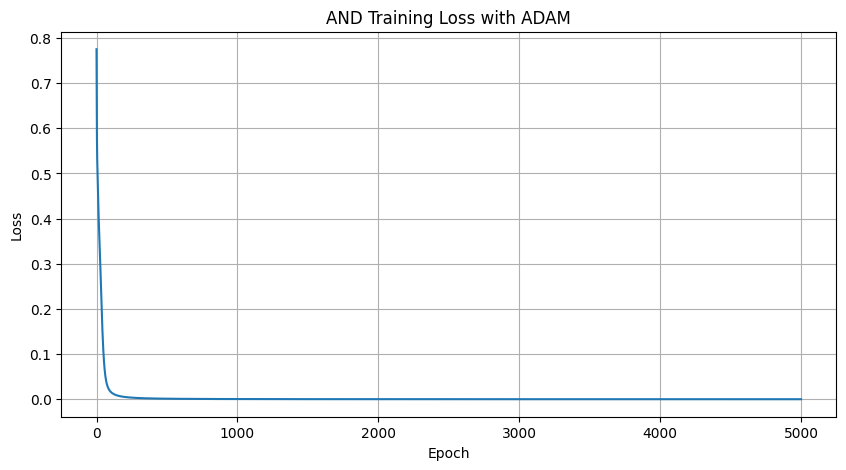


--- Logic Gate Neural Network Predictor ---
1. Train a Logic Gate Model
2. Predict Output for a Logic Gate
3. Exit
Enter your choice (1-3): 1

Select a logic gate to train:
1. AND
2. OR
3. NAND
4. NOR
5. XOR
Enter gate number: 2
You selected: OR
Choose optimizer (adam/sgd/rmsprop): adam

Model Architecture:
LogicGateMLP(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (sigmoid): Sigmoid()
  (output): Linear(in_features=4, out_features=1, bias=True)
)

Training OR gate model with ADAM optimizer...
Epoch [500/5000], Loss: 0.000366
Epoch [1000/5000], Loss: 0.000120
Epoch [1500/5000], Loss: 0.000060
Epoch [2000/5000], Loss: 0.000035
Epoch [2500/5000], Loss: 0.000023
Epoch [3000/5000], Loss: 0.000015
Epoch [3500/5000], Loss: 0.000011
Epoch [4000/5000], Loss: 0.000008
Epoch [4500/5000], Loss: 0.000006
Epoch [5000/5000], Loss: 0.000004
Training complete for OR. Final Loss: 0.000004, Accuracy: 100.00%
Trained model outputs:
tensor([[0.],
        [1.],
        [1.],
        [1.]

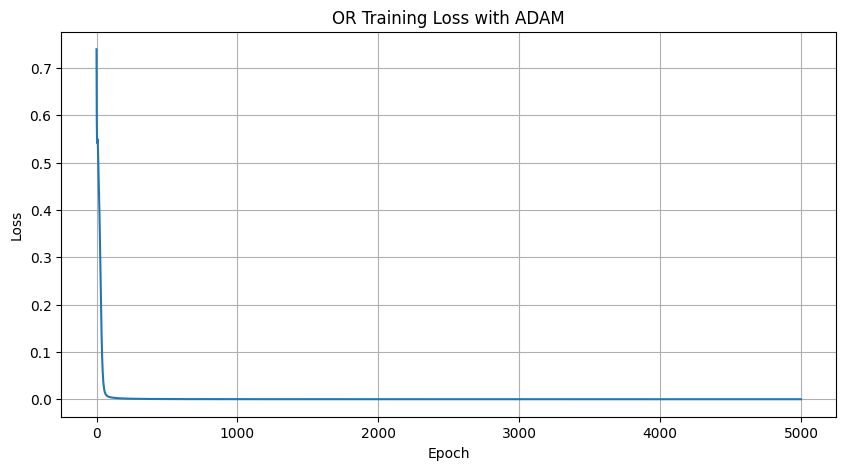


--- Logic Gate Neural Network Predictor ---
1. Train a Logic Gate Model
2. Predict Output for a Logic Gate
3. Exit
Enter your choice (1-3): 1

Select a logic gate to train:
1. AND
2. OR
3. NAND
4. NOR
5. XOR
Enter gate number: 3
You selected: NAND
Choose optimizer (adam/sgd/rmsprop): adam

Model Architecture:
LogicGateMLP(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (sigmoid): Sigmoid()
  (output): Linear(in_features=4, out_features=1, bias=True)
)

Training NAND gate model with ADAM optimizer...
Epoch [500/5000], Loss: 0.002039
Epoch [1000/5000], Loss: 0.000616
Epoch [1500/5000], Loss: 0.000300
Epoch [2000/5000], Loss: 0.000175
Epoch [2500/5000], Loss: 0.000112
Epoch [3000/5000], Loss: 0.000077
Epoch [3500/5000], Loss: 0.000054
Epoch [4000/5000], Loss: 0.000039
Epoch [4500/5000], Loss: 0.000029
Epoch [5000/5000], Loss: 0.000022
Training complete for NAND. Final Loss: 0.000022, Accuracy: 100.00%
Trained model outputs:
tensor([[1.],
        [1.],
        [1.],
      

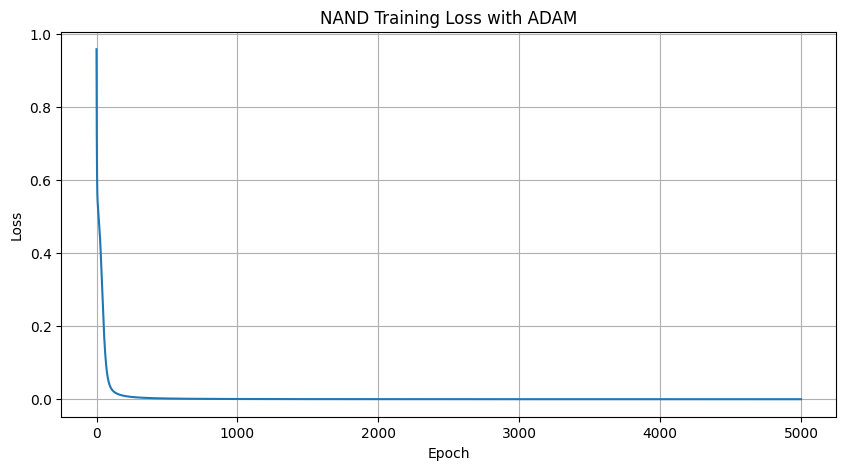


--- Logic Gate Neural Network Predictor ---
1. Train a Logic Gate Model
2. Predict Output for a Logic Gate
3. Exit
Enter your choice (1-3): 1

Select a logic gate to train:
1. AND
2. OR
3. NAND
4. NOR
5. XOR
Enter gate number: 4
You selected: NOR
Choose optimizer (adam/sgd/rmsprop): adam

Model Architecture:
LogicGateMLP(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (sigmoid): Sigmoid()
  (output): Linear(in_features=4, out_features=1, bias=True)
)

Training NOR gate model with ADAM optimizer...
Epoch [500/5000], Loss: 0.000333
Epoch [1000/5000], Loss: 0.000110
Epoch [1500/5000], Loss: 0.000055
Epoch [2000/5000], Loss: 0.000032
Epoch [2500/5000], Loss: 0.000021
Epoch [3000/5000], Loss: 0.000014
Epoch [3500/5000], Loss: 0.000010
Epoch [4000/5000], Loss: 0.000007
Epoch [4500/5000], Loss: 0.000005
Epoch [5000/5000], Loss: 0.000004
Training complete for NOR. Final Loss: 0.000004, Accuracy: 100.00%
Trained model outputs:
tensor([[1.],
        [0.],
        [0.],
        [

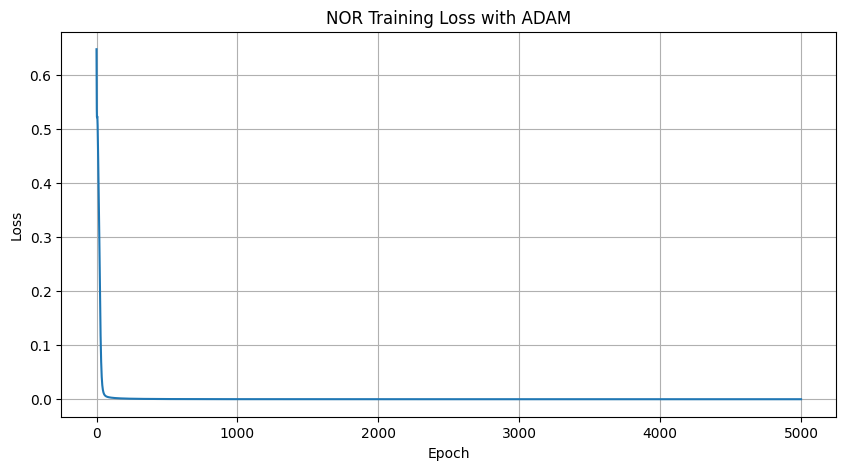


--- Logic Gate Neural Network Predictor ---
1. Train a Logic Gate Model
2. Predict Output for a Logic Gate
3. Exit
Enter your choice (1-3): 1

Select a logic gate to train:
1. AND
2. OR
3. NAND
4. NOR
5. XOR
Enter gate number: 5
You selected: XOR
Choose optimizer (adam/sgd/rmsprop): rmsprop

Model Architecture:
LogicGateMLP(
  (hidden): Linear(in_features=2, out_features=4, bias=True)
  (sigmoid): Sigmoid()
  (output): Linear(in_features=4, out_features=1, bias=True)
)

Training XOR gate model with RMSPROP optimizer...
Epoch [500/5000], Loss: 0.479112
Epoch [1000/5000], Loss: 0.000512
Epoch [1500/5000], Loss: 0.000036
Epoch [2000/5000], Loss: 0.000003
Epoch [2500/5000], Loss: 0.000000
Epoch [3000/5000], Loss: 0.000000
Epoch [3500/5000], Loss: 0.000000
Epoch [4000/5000], Loss: 0.000000
Epoch [4500/5000], Loss: 0.000000
Epoch [5000/5000], Loss: 0.000000
Training complete for XOR. Final Loss: 0.000000, Accuracy: 100.00%
Trained model outputs:
tensor([[0.],
        [1.],
        [1.],
   

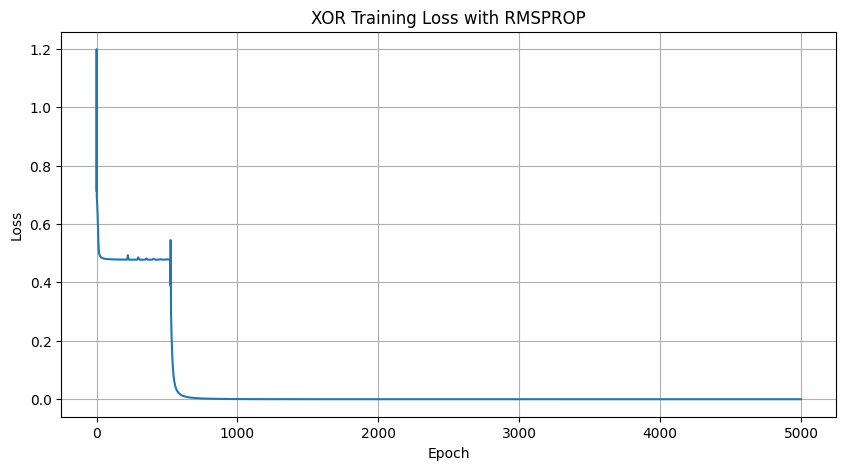


--- Logic Gate Neural Network Predictor ---
1. Train a Logic Gate Model
2. Predict Output for a Logic Gate
3. Exit
Enter your choice (1-3): 2

Select a logic gate for prediction:
1. AND
2. OR
3. NAND
4. NOR
5. XOR
Enter gate number: 3
Enter first binary input (0 or 1): 0
Enter second binary input (0 or 1): 0

--- NAND Gate Prediction ---
Inputs: (0, 0)
Predicted Output: 1
Confidence: 100.00%

--- Logic Gate Neural Network Predictor ---
1. Train a Logic Gate Model
2. Predict Output for a Logic Gate
3. Exit
Enter your choice (1-3): 2

Select a logic gate for prediction:
1. AND
2. OR
3. NAND
4. NOR
5. XOR
Enter gate number: 1
Enter first binary input (0 or 1): 0
Enter second binary input (0 or 1): 1

--- AND Gate Prediction ---
Inputs: (0, 1)
Predicted Output: 0
Confidence: 0.00%

--- Logic Gate Neural Network Predictor ---
1. Train a Logic Gate Model
2. Predict Output for a Logic Gate
3. Exit
Enter your choice (1-3): 2

Select a logic gate for prediction:
1. AND
2. OR
3. NAND
4. NOR
5. 

In [10]:
def main_menu():
    trained_models = {}

    while True:
        print("\n--- Logic Gate Neural Network Predictor ---")
        print("1. Train a Logic Gate Model")
        print("2. Predict Output for a Logic Gate")
        print("3. Exit")

        choice = input("Enter your choice (1-3): ")

        if choice == '1':
            print("\nSelect a logic gate to train:")
            for i, gate in enumerate(logic_gates_data.keys()):
                print(f"{i+1}. {gate}")

            gate_choice = input("Enter gate number: ")
            gate_names = list(logic_gates_data.keys())

            try:
                selected_gate_name = gate_names[int(gate_choice) - 1]
                print(f"You selected: {selected_gate_name}")

                # Prompt for optimizer choice
                while True:
                    optimizer_name = input("Choose optimizer (adam/sgd/rmsprop): ").lower()
                    if optimizer_name in ["adam", "sgd", "rmsprop"]:
                        break
                    else:
                        print("Invalid optimizer choice. Please enter 'adam', 'sgd', or 'rmsprop'.")

                trained_models[selected_gate_name] = train_model(
                    selected_gate_name, X, logic_gates_data[selected_gate_name], optimizer_name=optimizer_name # Pass optimizer_name
                )
            except (ValueError, IndexError):
                print("Invalid gate selection. Please try again.")

        elif choice == '2':
            print("\nSelect a logic gate for prediction:")
            for i, gate in enumerate(logic_gates_data.keys()):
                print(f"{i+1}. {gate}")

            gate_choice = input("Enter gate number: ")
            gate_names = list(logic_gates_data.keys())

            try:
                selected_gate_name = gate_names[int(gate_choice) - 1]

                if selected_gate_name not in trained_models:
                    print(f"Model for {selected_gate_name} not trained yet. Please train it first.")
                    continue

                while True:
                    try:
                        input1_str = input("Enter first binary input (0 or 1): ")
                        input1 = int(input1_str)
                        if input1 not in [0, 1]:
                            raise ValueError
                        break
                    except ValueError:
                        print("Invalid input. Please enter 0 or 1.")

                while True:
                    try:
                        input2_str = input("Enter second binary input (0 or 1): ")
                        input2 = int(input2_str)
                        if input2 not in [0, 1]:
                            raise ValueError
                        break
                    except ValueError:
                        print("Invalid input. Please enter 0 or 1.")

                predict_output(selected_gate_name, input1, input2)

            except (ValueError, IndexError):
                print("Invalid gate selection. Please try again.")

        elif choice == '3':
            print("Exiting application. Goodbye!")
            break

        else:
            print("Invalid choice. Please enter 1, 2, or 3.")

# Run the main menu
if __name__ == '__main__':
    main_menu()